In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
df = pd.read_csv('NKE.csv')
df.head()

,Date,Close,High,Low,Open,Volume
0,1/3/2000,4.471374,4.604934,4.436532,4.581707,8014400
1,1/4/2000,4.227483,4.395886,4.215869,4.366851,9810400
2,1/5/2000,4.471374,4.494601,4.250708,4.250708,6542400
3,1/6/2000,4.448146,4.448146,4.326200,4.448146,4891200
4,1/7/2000,4.448146,4.459760,4.366849,4.430726,3993600


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6559 entries, 0 to 6558
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    6559 non-null   object 
 1   Close   6559 non-null   float64
 2   High    6559 non-null   float64
 3   Low     6559 non-null   float64
 4   Open    6559 non-null   float64
 5   Volume  6559 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 307.6+ KB


In [4]:
df.describe()

,Close,High,Low,Open,Volume
count,6559.000000,6559.000000,6559.000000,6559.000000,6.559000e+03
mean,42.201151,42.637645,41.762623,42.200481,1.066901e+07
std,39.940264,40.360158,39.533845,39.956246,7.294436e+06
min,2.467967,2.514423,2.398283,2.502809,1.821900e+06
25%,8.364538,8.445401,8.305094,8.366846,6.505200e+06
50%,23.116028,23.278135,22.891102,23.082078,8.921700e+06
75%,70.471672,71.534835,69.971637,70.638438,1.264680e+07
max,166.246811,167.735935,164.364352,165.160424,1.299670e+08


In [51]:
df["Date"]=pd.to_datetime(df["Date"])
df.set_index("Date",inplace=True)

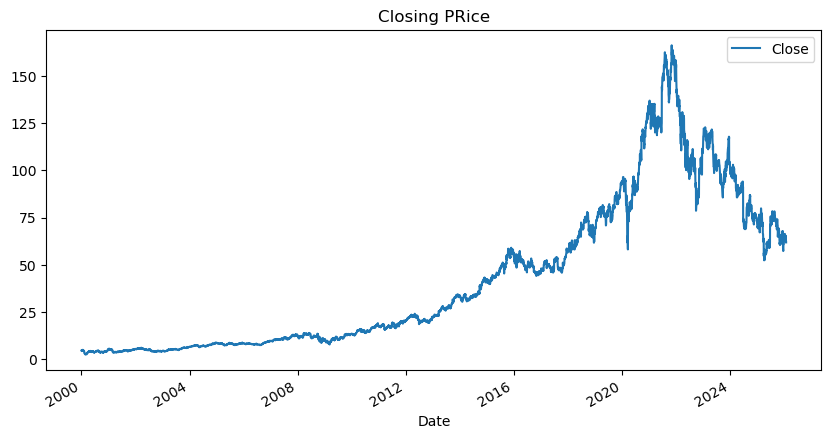

In [52]:
df[["Close"]].plot(figsize=(10,5))
plt.title("Closing PRice")
plt.show()

<Axes: >

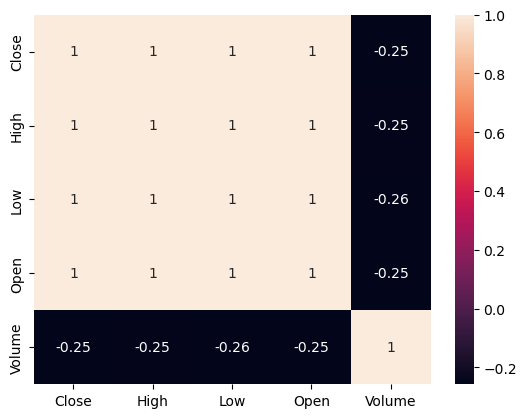

In [8]:
sns.heatmap(df.corr(),annot=True)

<Axes: xlabel='Date'>

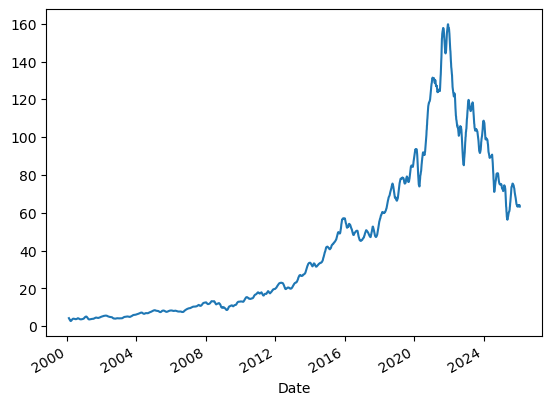

In [9]:
df["Close"].rolling(window=30).mean().plot()

<Axes: >

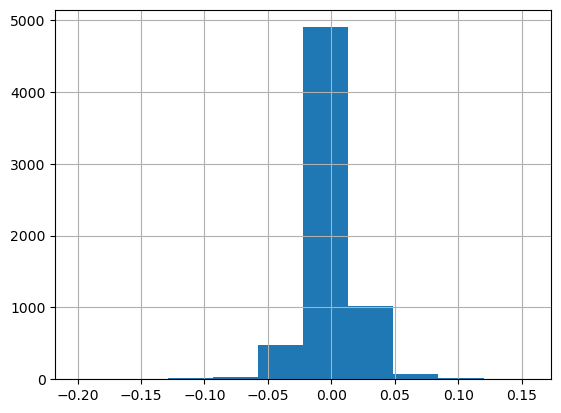

In [10]:
df["Close"].pct_change().hist()

In [ ]:
# pct_change=(current-previous)/previous

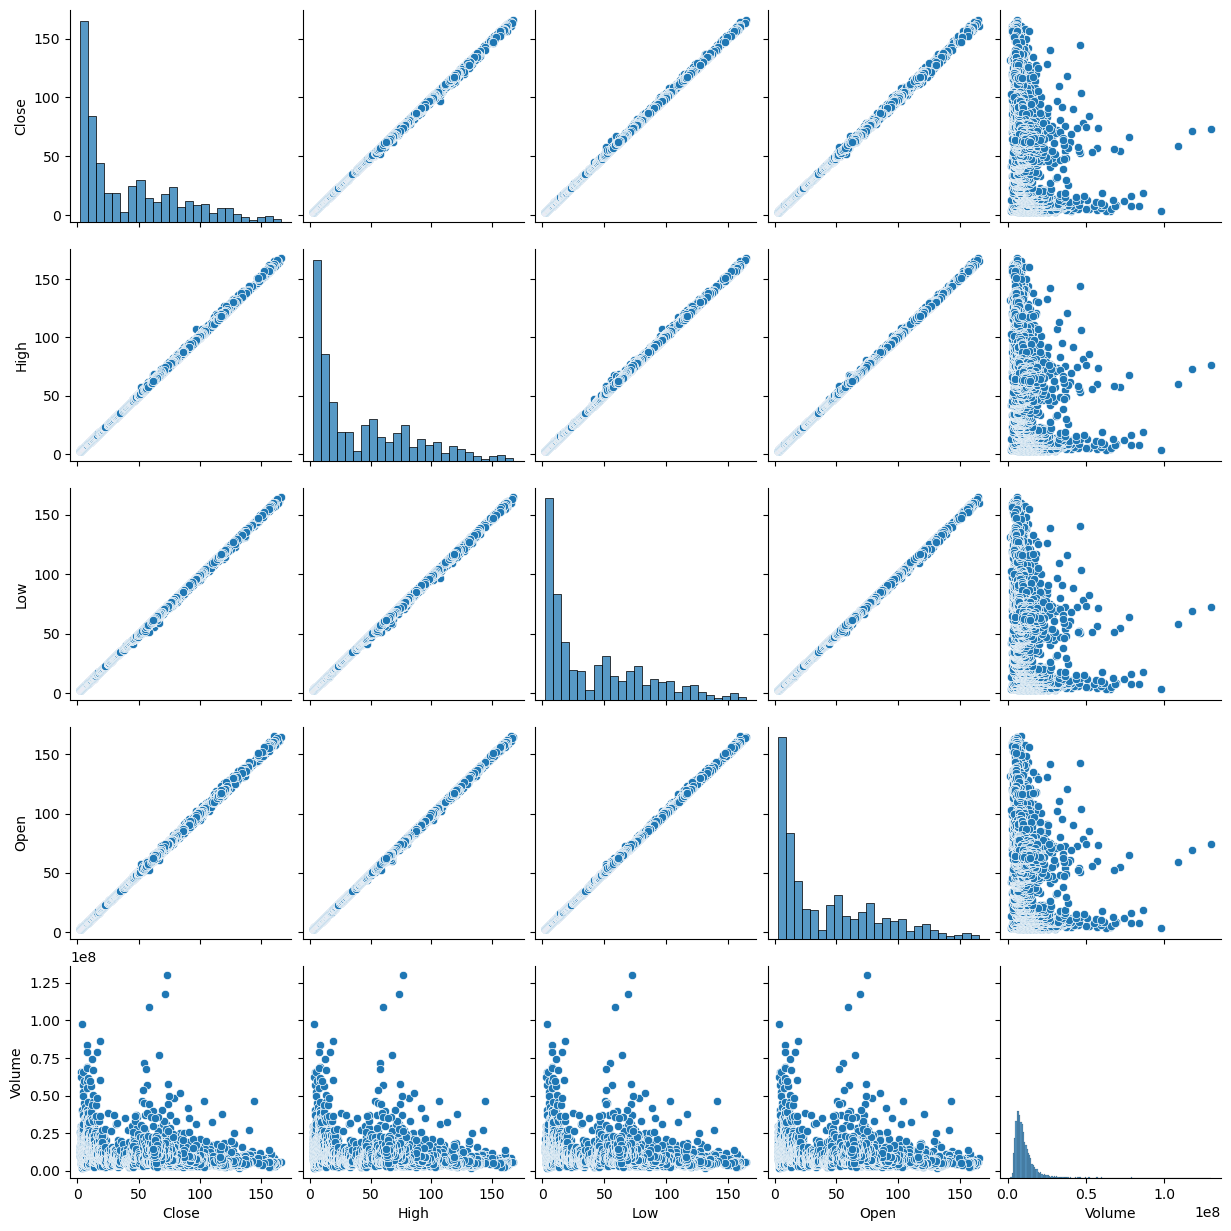

In [11]:
sns.pairplot(df)

In [16]:
df["MA50"]=df["Close"].rolling(50).mean()


In [17]:
df["MA200"]=df["Close"].rolling(200).mean()

<Axes: xlabel='Date'>

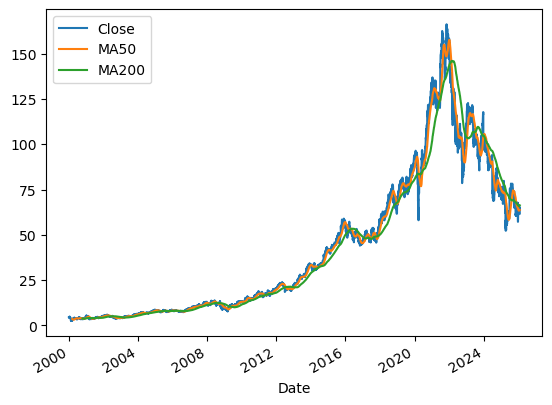

In [19]:
df[["Close","MA50","MA200"]].plot()

In [20]:
df["Daily Return"]=df["Close"].pct_change()

<Axes: xlabel='Daily Return', ylabel='Count'>

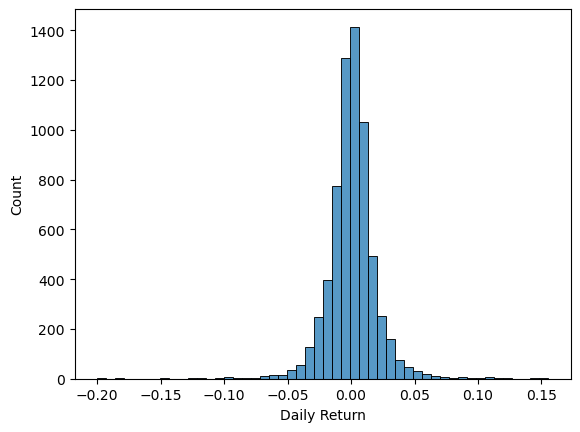

In [22]:
sns.histplot(df["Daily Return"],bins=50)

<Axes: xlabel='Date'>

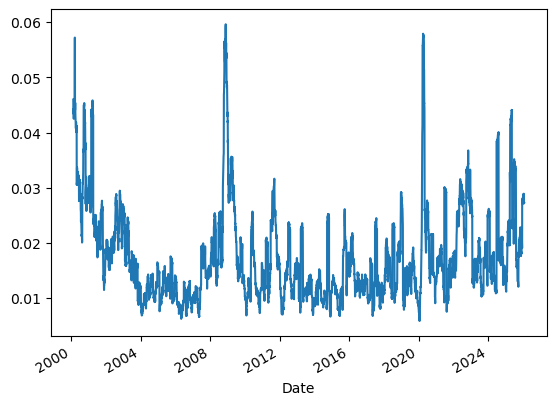

In [24]:
df["Volatility"]=df["Daily Return"].rolling(30).std()
df["Volatility"].plot()

<Axes: xlabel='Date'>

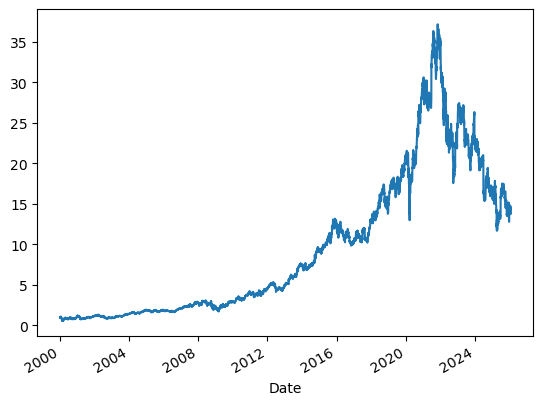

In [25]:
df["Cumulative Return"]=(1+df["Daily Return"]).cumprod()
df["Cumulative Return"].plot()

In [ ]:
# 0.01+1=101%

In [ ]:
# Machine Learning Modelling 

In [53]:
df=df.dropna()
X=df[["Open","High","Low","Volume"]]
y=df["Close"]

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train , X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,shuffle=False
)

In [11]:
from sklearn.linear_model import LinearRegression

In [12]:
model=LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
predictions=model.predict(X_test)

In [14]:
# print(predictions[:3])

[121.9860936  118.15932888 119.31517931]


In [17]:
from sklearn.metrics import mean_squared_error

In [18]:
mse=mean_squared_error(y_test,predictions)

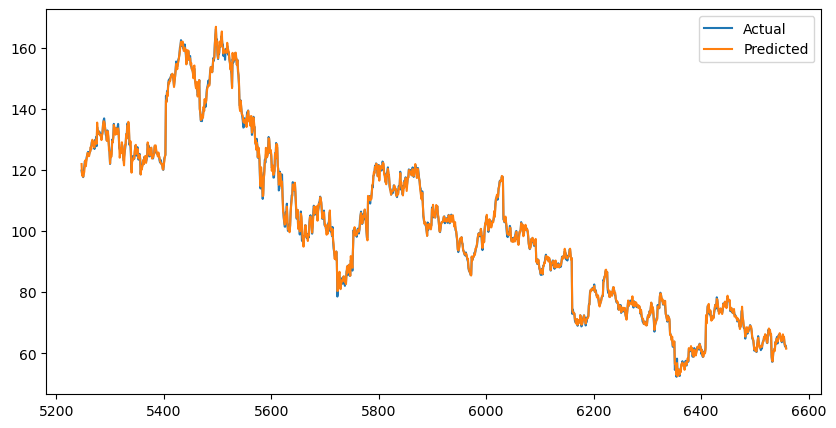

In [54]:
plt.figure(figsize=(10,5))
plt.plot(y_test.index,y_test,label="Actual")
plt.plot(y_test.index,predictions,label="Predicted")
plt.legend()
plt.show()

In [20]:
 # Random Forest Regressor 

In [22]:
from sklearn.ensemble import RandomForestRegressor

In [55]:
rf_model=RandomForestRegressor(n_estimators=100)
rf_model.fit(X_train,y_train)

rf_predictions=rf_model.predict(X_test)

In [24]:
# print(rf_predictions[:5])

[120.35092711 118.92733445 118.83969523 117.798529   119.12937377]


In [25]:
rf_mse=mean_squared_error(y_test,rf_predictions)

In [30]:
from sklearn.tree import DecisionTreeRegressor

In [34]:
dt_model=DecisionTreeRegressor()


In [37]:
dt_model.fit(X_train,y_train)

dt_predictions=dt_model.predict(X_test)

In [39]:
# print(dt_predictions[:5])

[120.3149719 118.9580994 118.6328278 117.6941605 119.4134674]


In [40]:
from sklearn.svm import SVR

In [41]:
svr_model=SVR()

In [42]:
svr_model.fit(X_train,y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [43]:
svr_predictions=svr_model.predict(X_test)

In [45]:
print(svr_predictions[:5])

[25.53826251 23.25677188 32.15983552 38.08994614 41.55366553]


In [46]:
print("Linear Regression MSE:",mse)

Linear Regression MSE: 0.45880047056232687


In [47]:
print("Random Forest MSE:",rf_mse)

Random Forest MSE: 128.4586630838217


In [ ]:
# Lower MSE=Better Model

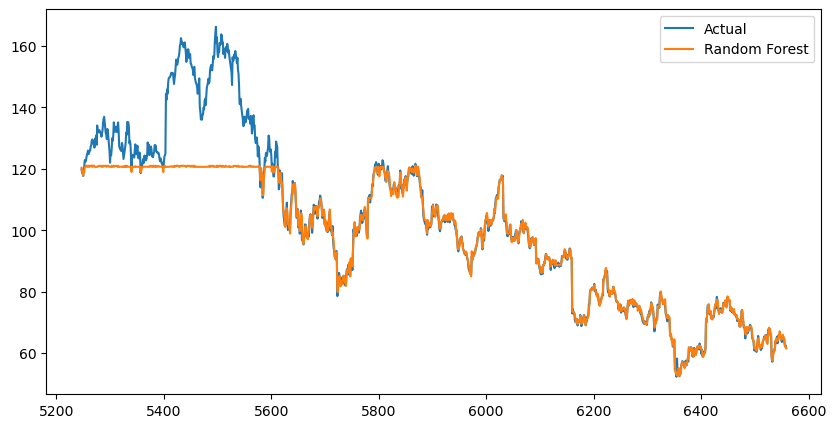

In [48]:
plt.figure(figsize=(10,5))
plt.plot(y_test.index,y_test,label="Actual")
plt.plot(y_test.index,rf_predictions,label="Random Forest")
plt.legend()
plt.show()

In [ ]:
#  Can we predict whether stock price will go UP or DOWN?

In [59]:
df["Target"]=(df["Close"].shift(-1)>df["Close"]).astype(int)
df=df.dropna()
X=df[["Open","High","Low","Target"]]
y=df["Target"]
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,shuffle=False
)

from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,y_train)

predictions=model.predict(X_test)

from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,predictions)

print("Accuracy:",accuracy)

Accuracy: 1.0


In [ ]:
# Visualization

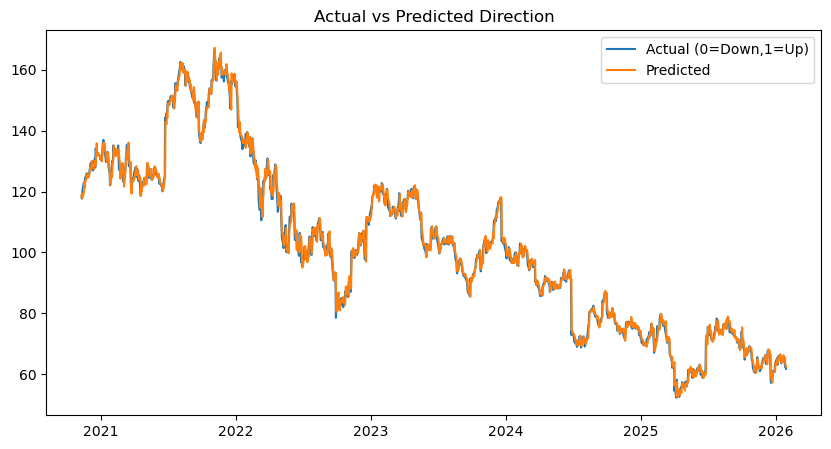

In [75]:
plt.figure(figsize=(10,5))
plt.plot(y_test.index, y_test, label="Actual (0=Down,1=Up)")
plt.plot(y_test.index, predictions, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Direction")
plt.show()

In [ ]:
#  What is the accuracy of our classification model?

In [62]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,predictions)
print("Model Accuracy:",accuracy)

Model Accuracy: 1.0


In [ ]:
# Visualization

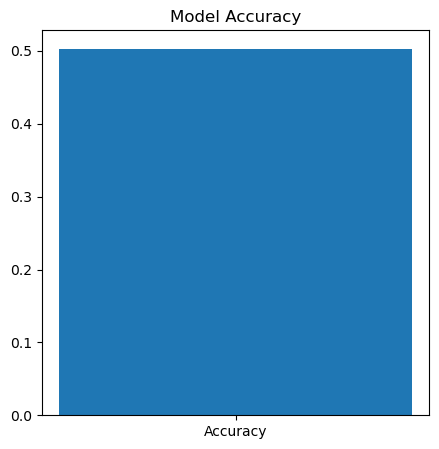

In [76]:
plt.figure(figsize=(5,5))
plt.bar(["Accuracy"],[accuracy])
plt.title("Model Accuracy")
plt.show()

In [ ]:
# - Can we add lag features to improve prediction?

In [67]:
df["Lag_1"]=df["Close"].shift(1)
df["Lag_2"]=df["Close"].shift(2)
df["Lag_3"]=df["Close"].shift(3)

df=df.dropna()

X=df[["Open","High","Low","Volume","Lag_1","Lag_2","Lag_3"]]
y=df["Target"]

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,shuffle=False
)

from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(X_train,y_train)

predictions=model.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,predictions)

print("Accuracy With Lag Feature:",accuracy)

Accuracy With Lag Feature: 0.5030534351145038


In [ ]:
# Visualization

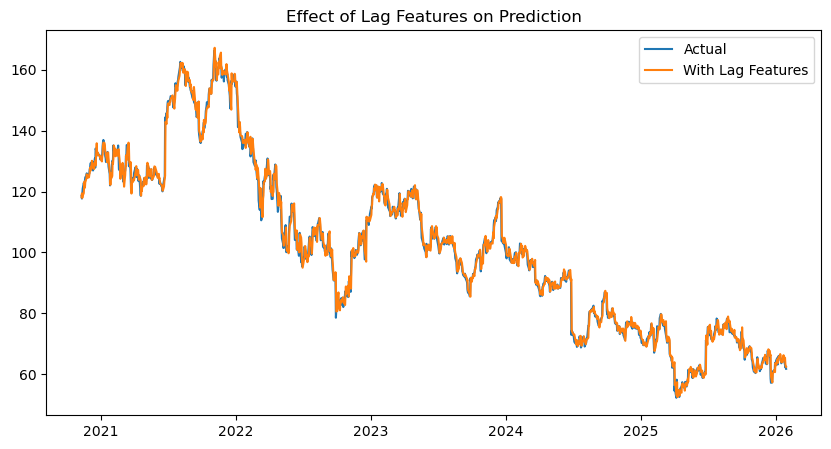

In [77]:
plt.figure(figsize=(10,5))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, predictions, label="With Lag Features")
plt.legend()
plt.title("Effect of Lag Features on Prediction")
plt.show()

In [ ]:
#  Which feature affects stock price the most?()

In [69]:
model=RandomForestClassifier()
model.fit(X_train,y_train)

import pandas as pd

feature_importance=model.feature_importances_

importance_df=pd.DataFrame({
    "Feature":X.columns,
    "Importance":feature_importance
})

importance_df=importance_df.sort_values(by="Importance",ascending=False)

print(importance_df)

  Feature  Importance
3  Volume    0.157462
6   Lag_3    0.143130
1    High    0.142590
4   Lag_1    0.140584
5   Lag_2    0.140542
0    Open    0.138145
2     Low    0.137547


In [ ]:
# Visualization

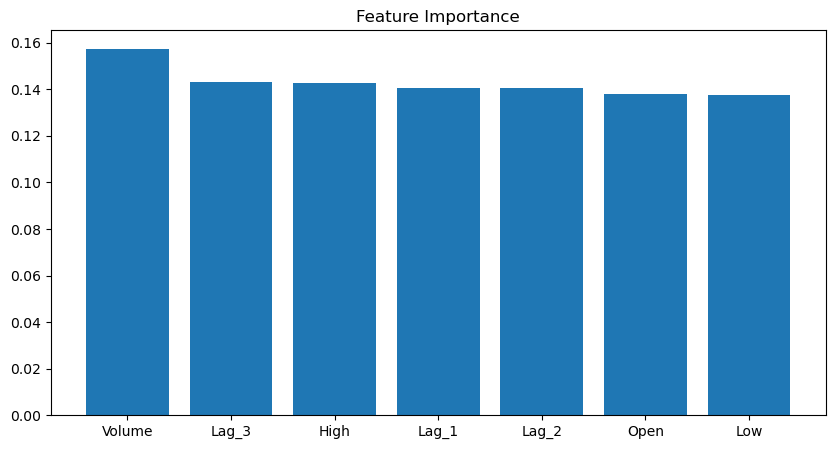

In [78]:
plt.figure(figsize=(10,5))
plt.bar(importance_df["Feature"], importance_df["Importance"])
plt.title("Feature Importance")
plt.show()

In [ ]:
# Can we predict next day closing price?

In [70]:
df["Next_Close"]=df["Close"].shift(-1)
df=df.dropna()

X=df[["Open","High","Low","Volume"]]
y=df["Next_Close"]

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,shuffle=False
)

model=LinearRegression()
model.fit(X_train,y_train)

predictions=model.predict(X_test)

mse=mean_squared_error(y_test,predictions)

print("MSE:",mse)

MSE: 5.117626563095049


In [ ]:
# Visualization

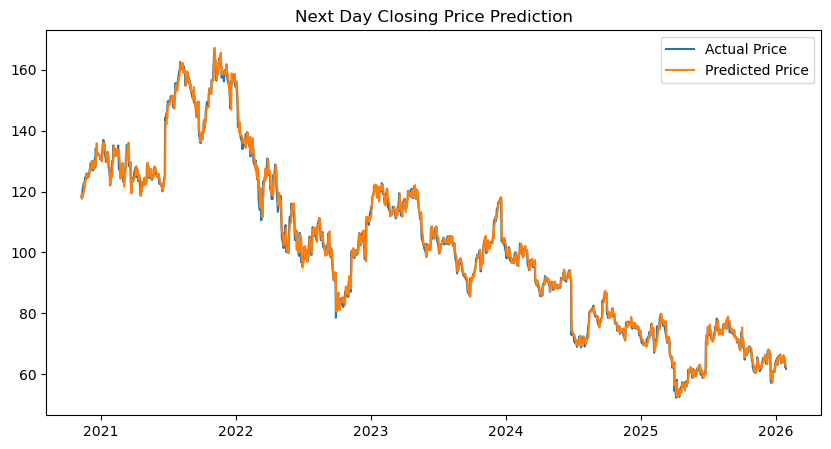

In [80]:
plt.figure(figsize=(10,5))
plt.plot(y_test.index, y_test, label="Actual Price")
plt.plot(y_test.index, predictions, label="Predicted Price")
plt.legend()
plt.title("Next Day Closing Price Prediction")
plt.show()

In [ ]:
# How good is our regression model (R² score)?

In [71]:
from sklearn.metrics import r2_score

r2=r2_score(y_test,predictions)
print("R2 Score:",r2)

R2 Score: 0.9933116825235749


In [ ]:
# R2=1-(Model Error/Total Variance)

In [ ]:
# Visualization

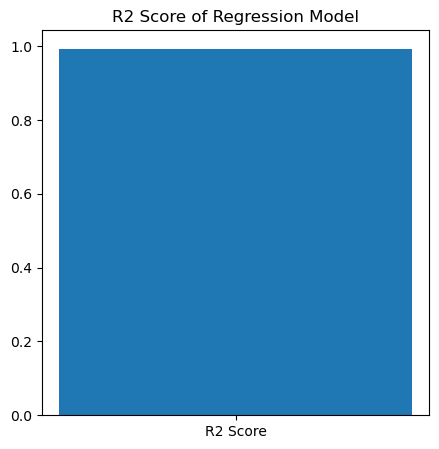

In [79]:
plt.figure(figsize=(5,5))
plt.bar(["R2 Score"], [r2])
plt.title("R2 Score of Regression Model")
plt.show()

In [ ]:
# Can we normalize data before training?

In [74]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)

X_test_scaled=scaler.transform(X_test)

model=LinearRegression()
model.fit(X_train_scaled,y_train)

predictions=model.predict(X_test_scaled)

results_df=pd.DataFrame({
    "Actual":y_test.values,
    "Predicted":predictions
},index=y_test.index)
print(results_df.head(10))

                Actual   Predicted
Date                              
2020-11-10  118.642113  118.180904
2020-11-11  117.694160  119.391325
2020-11-12  119.218300  117.922465
2020-11-13  120.919044  118.596216
2020-11-16  122.870697  119.492001
2020-11-17  122.331673  122.029492
2020-11-18  122.591881  123.261782
2020-11-19  123.586304  121.259675
2020-11-20  124.655075  122.984892
2020-11-23  125.184807  124.297743
